### Aviso e Bibliotecas
ATIVIDADE: SIMULADOR DE LANÇAMENTO DE UM PROJETIL

Instruções de Execução:
1. Certifique-se de ter o Python instalado.
2. Instale as dependências necessárias executando no terminal:
   - pip install numpy 
   - pip install matplotlib
3. Execute este script com o comando:
   teste_fisica.ipynb


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider, Button
import matplotlib.animation as animation

### Variavéis Iniciais

In [4]:
v0_init = 50.0      # m/s (Escala sugerida: 5 a 150)
alpha_init = 45.0   # Graus (Escala sugerida: 1 a 89)
y0_init = 10.0      # m (Escala sugerida: 0 a 50)
g_init = 9.81       # m/s² (Escala sugerida: 1.6 a 24.8)
x0 = 0.0            # Posição x inicial fixa em zero

anim = None
historico_curvas = []  # Lista para armazenar as curvas salvas

### 01. Funções para cálcular o resultado e trajetória.

In [5]:
def calcular_resultados(v0, alpha, y0, g):
    """Calcula os resultados numéricos pelas fórmulas analíticas fechadas (3), (4) e (5)."""
    theta = np.radians(alpha)
    
    # Equação (3): Tempo de voo
    termo_raiz = (v0 * np.sin(theta))**2 + 2 * g * y0
    tvoo = (v0 * np.sin(theta) + np.sqrt(termo_raiz)) / g
    
    # Equação (4): Altura máxima
    ymax = y0 + ((v0 * np.sin(theta))**2) / (2 * g)
    
    # Equação (5): Alcance horizontal total
    R = x0 + v0 * np.cos(theta) * tvoo
    
    return tvoo, ymax, R

In [6]:
def calcular_trajetoria(v0, alpha, y0, g, tvoo):
    """Gera os vetores x e y usando as equações temporárias fechadas (1) e (2)."""
    theta = np.radians(alpha)
    t = np.linspace(0, tvoo, 200) # 200 pontos de tempo garantem uma curva suave
    
    # Equações (1) e (2)
    x = x0 + v0 * np.cos(theta) * t
    y = y0 + v0 * np.sin(theta) * t - 0.5 * g * t**2
    return t, x, y

### 02. Configuração do Ambiente Gráfico

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


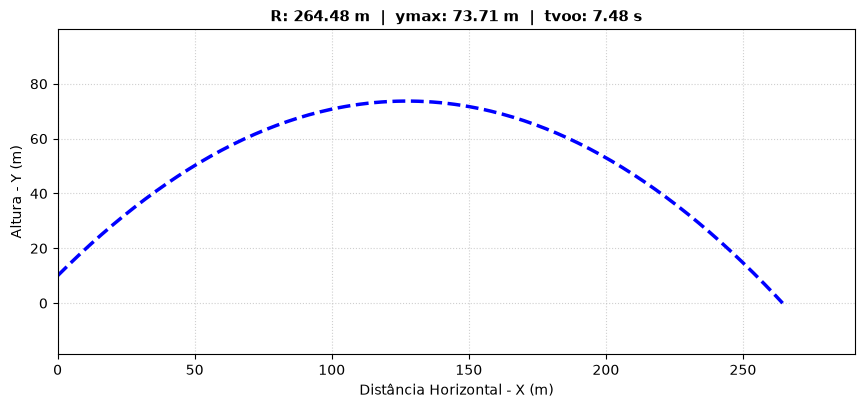

In [8]:
fig, ax = plt.subplots(figsize=(11, 6.5))
plt.subplots_adjust(bottom=0.38, right=0.85) # Espaço reservado para os controles

# Estado inicial do sistema
tvoo, ymax, R = calcular_resultados(v0_init, alpha_init, y0_init, g_init)
_, x_init, y_init = calcular_trajetoria(v0_init, alpha_init, y0_init, g_init, tvoo)

# Elementos visuais primários (Linha de visualização dinâmica atual)
linha_atual, = ax.plot(x_init, y_init, lw=2.5, color='blue', linestyle='--', label='Configuração Atual')
ponto_projetil, = ax.plot([], [], 'ro', ms=8, zorder=5) # Projétil vermelho para animação

# Ajustes de eixos e rótulos obrigatórios (Requisito 5)
ax.set_xlabel("Distância Horizontal - X (m)", fontsize=10)
ax.set_ylabel("Altura - Y (m)", fontsize=10)
ax.grid(True, linestyle=':', alpha=0.6)
titulo = ax.set_title(f"R: {R:.2f} m  |  ymax: {ymax:.2f} m  |  tvoo: {tvoo:.2f} s", fontsize=11, weight='bold')

# Escala consistente 1:1 para evitar distorções espaciais (Requisito 5)
ax.set_xlim(0, max(10, R * 1.1))
ax.set_ylim(0, max(10, ymax * 1.1))
ax.set_aspect('equal', adjustable='datalim')